<a href="https://colab.research.google.com/github/munhyunsik/ML/blob/ML/week13_report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1번

In [41]:
data = np.array([[0, 0, 0, 1, 1],
                [0, 0, 0, 0, 1],
                [2, 0, 0, 1, 0],
                [1, 2, 0, 1, 0],
                [1, 1, 1, 1, 0],
                [1, 1, 1, 0, 1],
                [2, 1, 1, 0, 0],
                [0, 2, 0, 1, 1],
                [0, 1, 1, 1, 0],
                [1, 2, 1, 1, 0],
                [0, 2, 1, 0, 0],
                [2, 2, 0, 0, 0],
                [2, 0, 1, 1, 0],
                [1, 2, 0, 0, 1]])
X = data[:,0:4]
y = data[:,4]

In [42]:
def entropy(y):
  values, counts = np.unique(y, return_counts = True)
  p = counts / counts.sum()
  return -np.sum(p * np.log2(p))

total_entropy = entropy(y)
print(f"전체 데이터 엔트로피 : {total_entropy:.4f}")

for feature_idx in range(X.shape[1]):
  feature_values = np.unique(X[:, feature_idx])
  feature_entropy = 0
  for value in feature_values:
    idx = X[:, feature_idx] == value
    subset_y = y[idx]
    weight = len(subset_y) / len(y)
    subset_entropy = entropy(subset_y)
    feature_entropy += weight * subset_entropy
  info_gain = total_entropy - feature_entropy
  print(f"Feature {feature_idx}의 정보 이득 : {info_gain:.4f}")

전체 데이터 엔트로피 : 0.9403
Feature 0의 정보 이득 : 0.2467
Feature 1의 정보 이득 : 0.0292
Feature 2의 정보 이득 : 0.1518
Feature 3의 정보 이득 : 0.0481


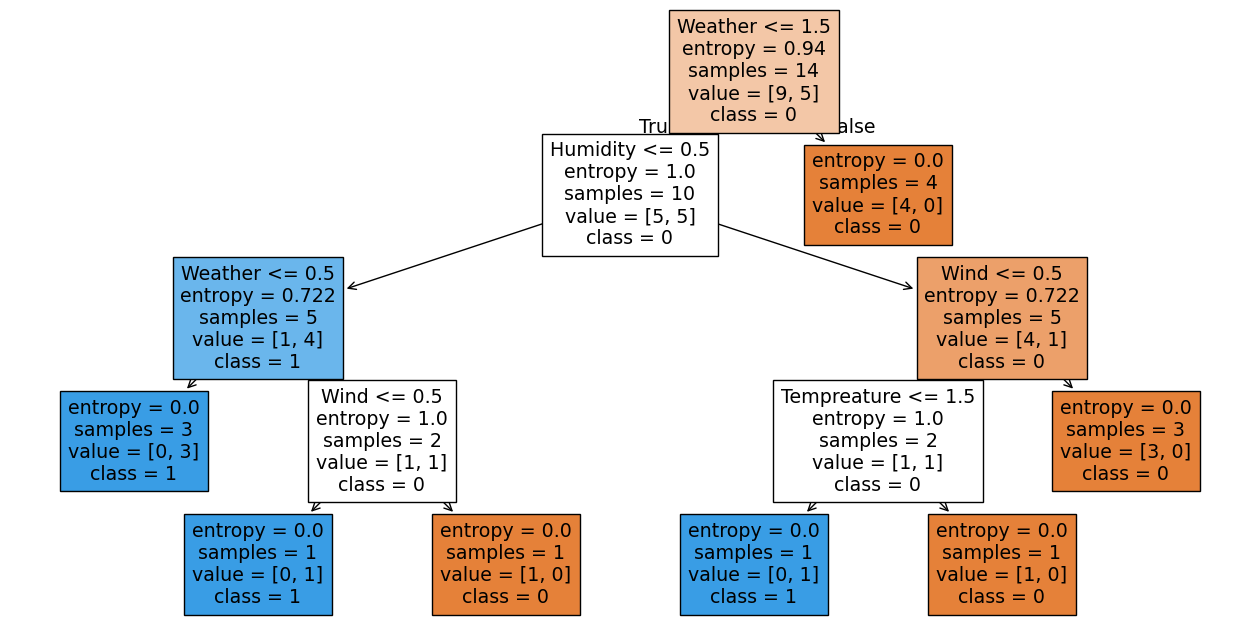

In [43]:
clf = tree.DecisionTreeClassifier(criterion='entropy', max_depth = 4, random_state = 0)
clf.fit(X,y)

# Decision Tree for binary classifier
plt.figure(figsize=(16,8))
tree.plot_tree(clf, feature_names=['Weather', 'Tempreature', 'Humidity', 'Wind'], class_names=['0', '1'], filled=True)
plt.show()

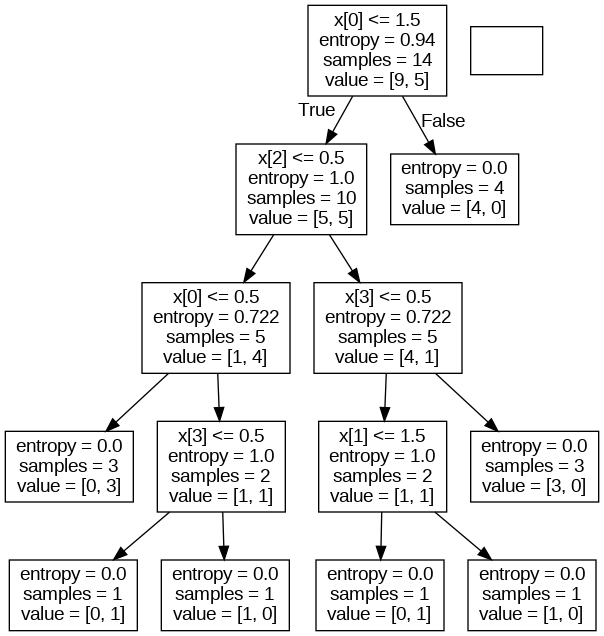

In [44]:
dot_data = export_graphviz(clf)
graph = pydotplus.graph_from_dot_data(dot_data)
Image(graph.create_png())

In [45]:
clf.predict([[1, 2, 0, 1]])

array([0])

2번

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [47]:
from sklearn.tree import export_graphviz
import pydotplus
from IPython.display import Image
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree


In [48]:
df = pd.read_csv('/content/drug200.csv')

In [49]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [50]:
df['Sex'] = df['Sex'].map({'F': 2, 'M': 1})
df['BP'] = df['BP'].map({'HIGH': 2, 'LOW': 1, 'NORMAL': 0})
df['Cholesterol'] = df['Cholesterol'].map({'HIGH': 2, 'LOW': 1, 'NORMAL': 0})
df['Drug'] = df['Drug'].map({'drugA': 1, 'drugB': 2, 'drugC': 3, 'drugX': 4, 'drugY': 5})
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,2,2,2,25.355,5
1,47,1,1,2,13.093,3
2,47,1,1,2,10.114,3
3,28,2,0,2,7.798,4
4,61,2,1,2,18.043,5


In [51]:
X = df.iloc[:, 0:5]
y = df['Drug']

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


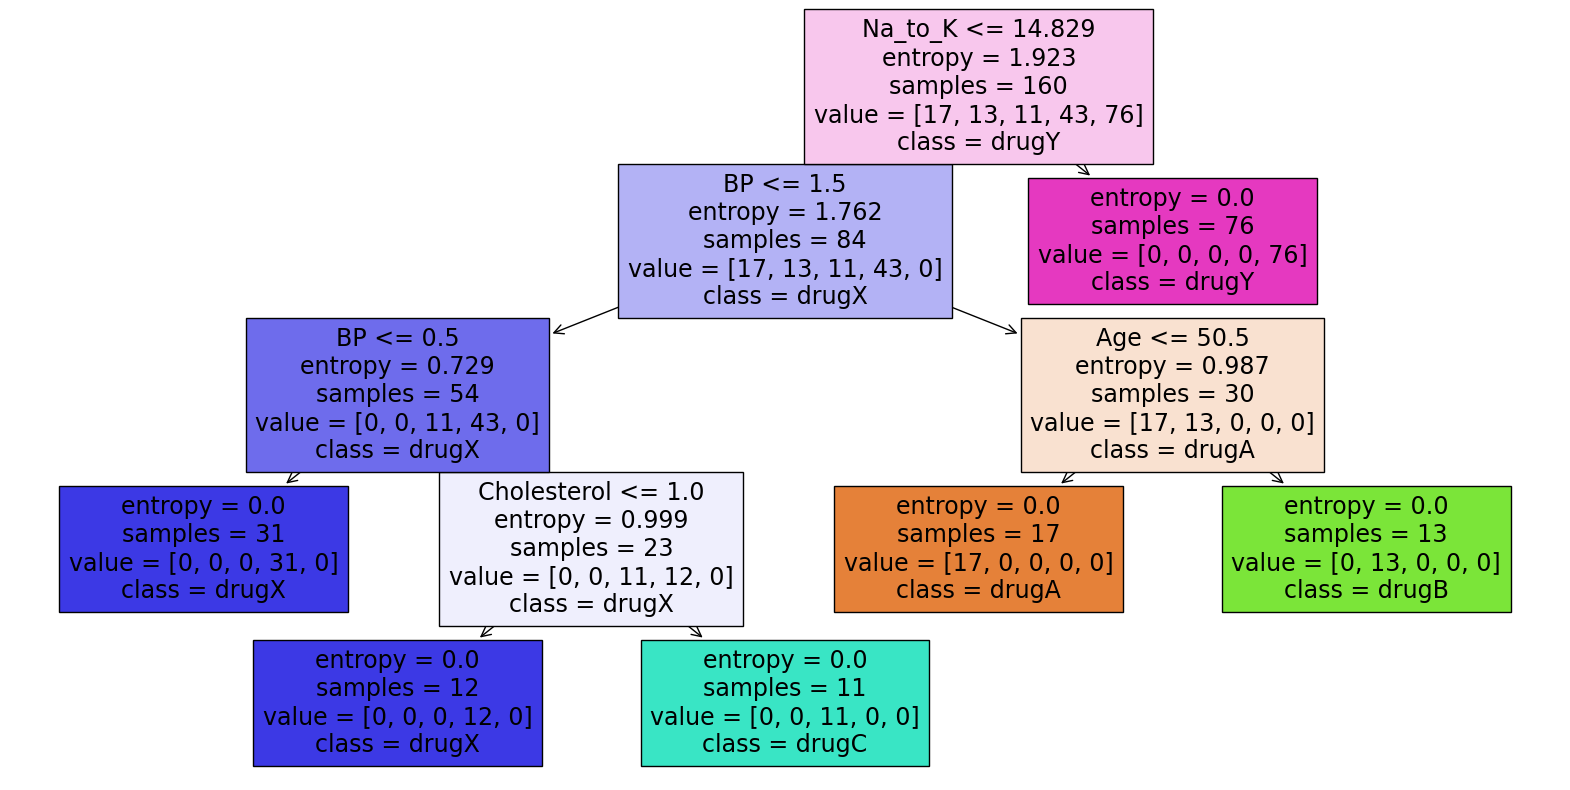

In [53]:
clf = DecisionTreeClassifier(criterion='entropy',max_depth = 5, random_state=42)
clf.fit(X_train, y_train)

plt.figure(figsize=(20,10))
tree.plot_tree(clf, feature_names=X.columns, class_names=['drugA','drugB','drugC','drugX','drugY'], filled=True)
plt.show()


In [54]:
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 1.0


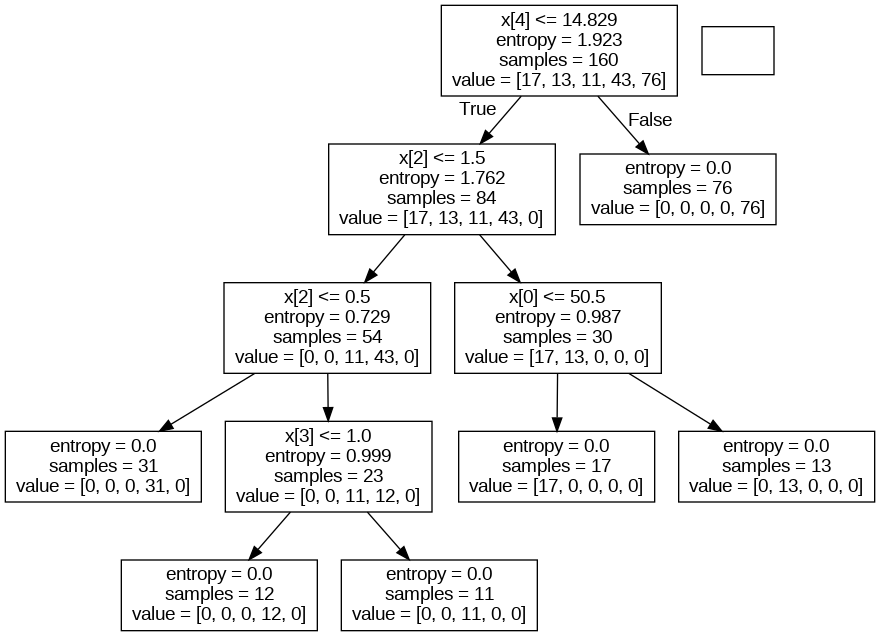

In [55]:
dot_data = export_graphviz(clf)
graph = pydotplus.graph_from_dot_data(dot_data)
Image(graph.create_png())

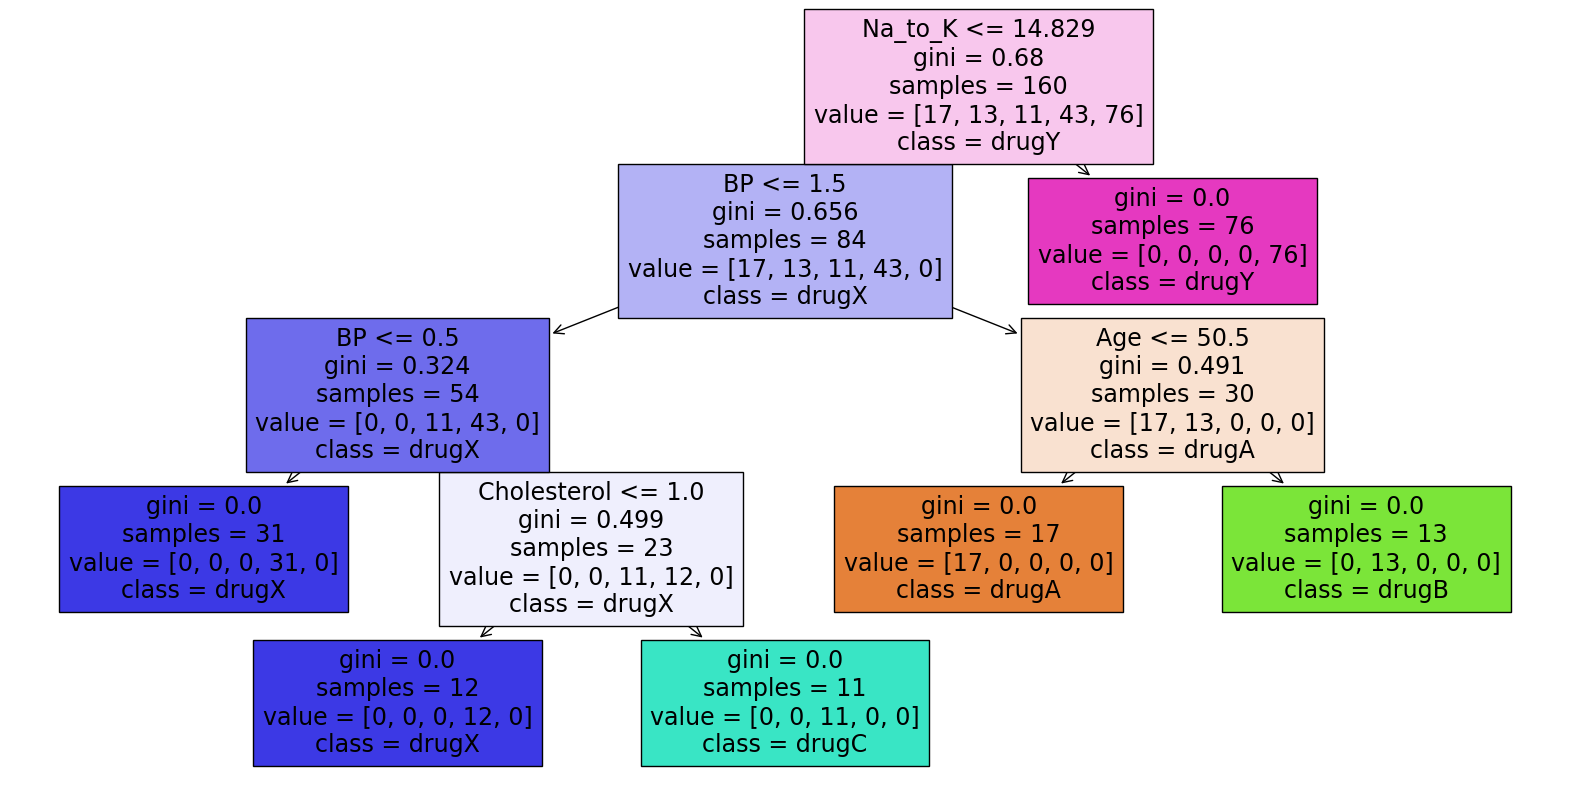

In [56]:
clf = DecisionTreeClassifier(criterion='gini',max_depth = 5, random_state=42)
clf.fit(X_train, y_train)

plt.figure(figsize=(20,10))
tree.plot_tree(clf, feature_names=X.columns, class_names=['drugA','drugB','drugC','drugX','drugY'], filled=True)
plt.show()

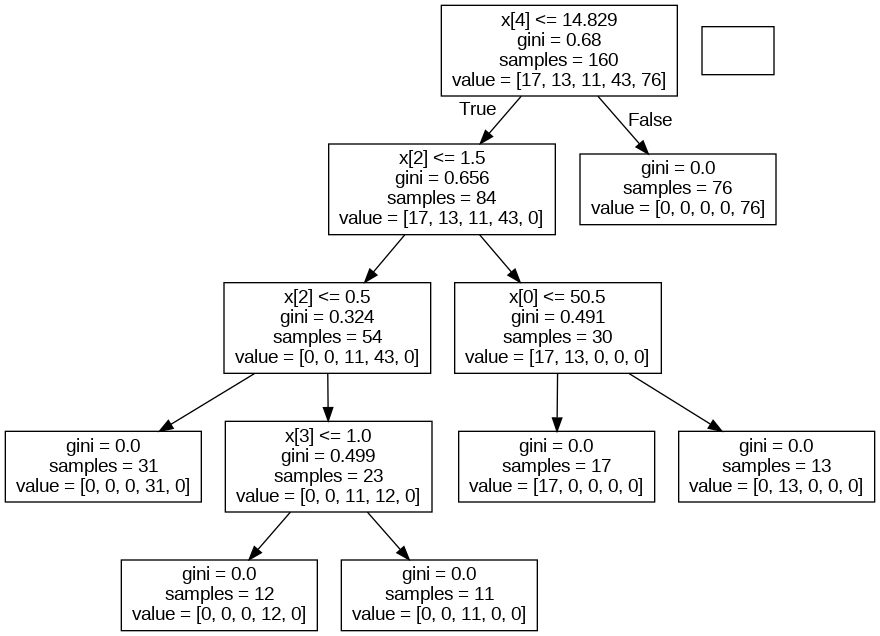

In [57]:
dot_data = export_graphviz(clf)
graph = pydotplus.graph_from_dot_data(dot_data)
Image(graph.create_png())